# `geo-tfidf`

# imports

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import sklearn
import datasets
import duckdb
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import plotnine as p9
from sklearn.feature_extraction.text import TfidfVectorizer
print(pd.__version__)
print(np.__version__)
print(sklearn.__version__)
print(datasets.__version__)
print(duckdb.__version__)

3.0.3
2.4.6
1.8.0
4.8.5
1.5.3


# path

In [2]:
DATA_DIR = Path.cwd().parent / "data"

print(f"data dir: {DATA_DIR}")
PLOT_DIR = Path.cwd() / "img"
print(f"plot dir: {PLOT_DIR}")

data dir: /mnt/data/projects/geo-tfidf/data
plot dir: /mnt/data/projects/geo-tfidf/notebooks/img


# load dataset from huggingface

In [3]:
ds = datasets.load_dataset('wangrongsheng/ag_news', split='train[:5000]')
print(ds)

Dataset({
    features: ['text', 'label'],
    num_rows: 5000
})


# pandas eda

In [4]:
df = pd.DataFrame(ds)
print(df)

                                                   text  label
0     Wall St. Bears Claw Back Into the Black (Reute...      2
1     Carlyle Looks Toward Commercial Aerospace (Reu...      2
2     Oil and Economy Cloud Stocks' Outlook (Reuters...      2
3     Iraq Halts Oil Exports from Main Southern Pipe...      2
4     Oil prices soar to all-time record, posing new...      2
...                                                 ...    ...
4995  Court to hear medal appeal  Britain will find ...      0
4996  Guatemala to pay paramilitaries Guatemala's go...      0
4997  Particle collider edges forward Physicists tak...      0
4998  Oil Futures Rise to Record as Iraq Fighting Th...      2
4999  General Growth Properties to acquire Rouse for...      2

[5000 rows x 2 columns]


In [5]:
df.columns

Index(['text', 'label'], dtype='str')

In [6]:
df.label.unique()

array([2, 3, 1, 0])

In [7]:
# World (0), Sports (1), Business (2), Sci/Tech (3)
df = df.assign(
    label = lambda d: (
        d.label.astype("category")).
        cat.rename_categories({0: "World", 1: "Sports", 2: "Business", 3: "Sci/Tech"})
)

In [8]:
df.dtypes

text          str
label    category
dtype: object

In [9]:
print(df['label'].value_counts().sort_values())


label
Sports      1032
World       1235
Business    1236
Sci/Tech    1497
Name: count, dtype: int64


In [10]:
df.index

RangeIndex(start=0, stop=5000, step=1)

In [11]:
df['label']

0       Business
1       Business
2       Business
3       Business
4       Business
          ...   
4995       World
4996       World
4997       World
4998    Business
4999    Business
Name: label, Length: 5000, dtype: category
Categories (4, str): ['World', 'Sports', 'Business', 'Sci/Tech']

In [12]:
df.label.unique()

['Business', 'Sci/Tech', 'Sports', 'World']
Categories (4, str): ['World', 'Sports', 'Business', 'Sci/Tech']

In [13]:
df['text']

0       Wall St. Bears Claw Back Into the Black (Reute...
1       Carlyle Looks Toward Commercial Aerospace (Reu...
2       Oil and Economy Cloud Stocks' Outlook (Reuters...
3       Iraq Halts Oil Exports from Main Southern Pipe...
4       Oil prices soar to all-time record, posing new...
                              ...                        
4995    Court to hear medal appeal  Britain will find ...
4996    Guatemala to pay paramilitaries Guatemala's go...
4997    Particle collider edges forward Physicists tak...
4998    Oil Futures Rise to Record as Iraq Fighting Th...
4999    General Growth Properties to acquire Rouse for...
Name: text, Length: 5000, dtype: str

# wordcloud

In [14]:
text_str = df['text'].to_string()

In [15]:
wordcloud = WordCloud().generate(text=text_str)

In [16]:
# show wordcloud as image (without matplotlib)
#wordcloud_image = wordcloud.to_image()
#wordcloud_image.show()

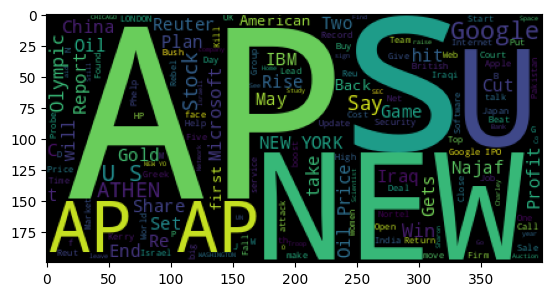

In [17]:
# show wordcloud with matplotlib
plt.imshow(wordcloud)

# tf-idf vectorize

In [18]:
vec = TfidfVectorizer(stop_words='english', max_features=5000)
X = vec.fit_transform(df['text'])

In [19]:
print(X.shape)

(5000, 5000)


In [20]:
print(X)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 94720 stored elements and shape (5000, 5000)>
  Coords	Values
  (0, 4835)	0.4062381886320395
  (0, 4228)	0.2389113138886263
  (0, 480)	0.2957578565401446
  (0, 848)	0.3017793023408226
  (0, 538)	0.25886522398848
  (0, 3742)	0.20325324863420116
  (0, 4031)	0.2317894551088903
  (0, 3946)	0.2957578565401446
  (0, 4310)	0.20417489041131115
  (0, 1427)	0.3017793023408226
  (0, 442)	0.28594099286806973
  (0, 3932)	0.2818253922409689
  (0, 1949)	0.2363903051748063
  (1, 3742)	0.220821856039363
  (1, 2641)	0.2640334395218726
  (1, 915)	0.2836664820770574
  (1, 3393)	0.26563508195936403
  (1, 2336)	0.26100082917187784
  (1, 1745)	0.21847101308887312
  (1, 1958)	0.19125998785966156
  (1, 3697)	0.3356016604394785
  (1, 2695)	0.23085924931484747
  (1, 1001)	0.29190616966970845
  (1, 3285)	0.3106568834060967
  (1, 1183)	0.2484277560356661
  :	:
  (4999, 523)	0.11533108130036342
  (4999, 927)	0.0923693371846904
  (4999, 1882)	0.2767349688

In [21]:
type(X)

scipy.sparse._csr.csr_matrix

In [22]:
vocab = vec.get_feature_names_out()
len(vocab)

5000

In [23]:
type(vocab)

numpy.ndarray

In [24]:
print(vocab)

['00' '000' '01' ... 'zone' 'zoo' 'zurich']


In [25]:
type(vocab[0])

str

# tf-idf per-class mean

In [26]:
records = []
for label, idx in df.groupby('label').groups.items():
    means = np.asarray(X[idx].mean(axis=0)).ravel()
    top = means.argsort()[::-1][:5]
    records.extend(
        {'label': label, 'term': vocab[j], 'mean_tfidf': means[j]}
        for j in top
    )

In [27]:
mean_tfidf_per_class = (
    pd.DataFrame.from_records(records)
    .sort_values(
        ['label', 'mean_tfidf'],
        ascending=[True, False],
    )
    .reset_index(drop=True)
)
print(mean_tfidf_per_class)

       label       term  mean_tfidf
0   Business    reuters    0.040898
1   Business        oil    0.037846
2   Business     google    0.031398
3   Business     prices    0.027439
4   Business        new    0.027150
5   Sci/Tech         ap    0.022761
6   Sci/Tech  microsoft    0.020009
7   Sci/Tech        new    0.019605
8   Sci/Tech   software    0.016425
9   Sci/Tech    windows    0.015580
10    Sports     athens    0.045654
11    Sports         39    0.039463
12    Sports    olympic    0.033227
13    Sports         ap    0.032064
14    Sports       gold    0.029905
15     World         ap    0.025665
16     World      najaf    0.024167
17     World    reuters    0.022125
18     World       said    0.020920
19     World       iraq    0.020817


# plot with plotnine

In [28]:
mean_tfidf_per_class.T

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
label,Business,Business,Business,Business,Business,Sci/Tech,Sci/Tech,Sci/Tech,Sci/Tech,Sci/Tech,Sports,Sports,Sports,Sports,Sports,World,World,World,World,World
term,reuters,oil,google,prices,new,ap,microsoft,new,software,windows,athens,39,olympic,ap,gold,ap,najaf,reuters,said,iraq
mean_tfidf,0.040898,0.037846,0.031398,0.027439,0.02715,0.022761,0.020009,0.019605,0.016425,0.01558,0.045654,0.039463,0.033227,0.032064,0.029905,0.025665,0.024167,0.022125,0.02092,0.020817


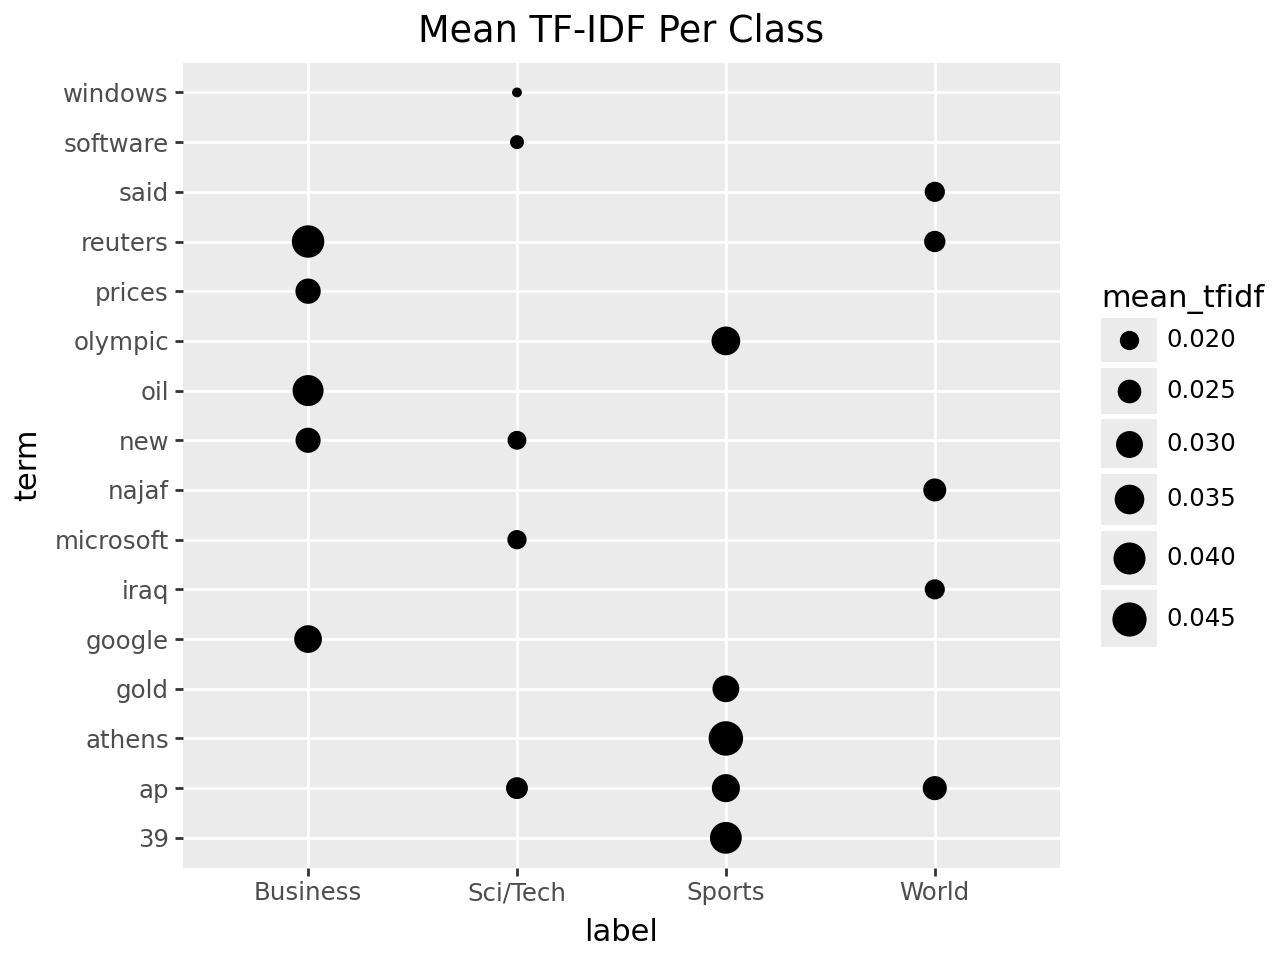

In [29]:
plot = (
    p9.ggplot(data=mean_tfidf_per_class, mapping=p9.aes(x="label", y="term", size="mean_tfidf")) +
    p9.geom_point() +
    p9.theme_grey() +
    p9.labs(title="Mean TF-IDF Per Class")
)
plot

# sql eda

In [30]:
query = """
select * 
from df
"""


In [31]:
duckdb.sql(query).df()

,text,label
0,Wall St. Bears Claw Back Into the Black (Reute...,Business
1,Carlyle Looks Toward Commercial Aerospace (Reu...,Business
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,Business
3,Iraq Halts Oil Exports from Main Southern Pipe...,Business
4,"Oil prices soar to all-time record, posing new...",Business
...,...,...
4995,Court to hear medal appeal Britain will find ...,World
4996,Guatemala to pay paramilitaries Guatemala's go...,World
4997,Particle collider edges forward Physicists tak...,World
4998,Oil Futures Rise to Record as Iraq Fighting Th...,Business
